# 개념-예시-실습 묶음 정확도 평가 (item06)

**평가 질문**: LLM 토픽 추출 파이프라인이 각 개념에 예시·실습을 올바르게 묶는가?

**입력 (파이프라인)**: `data/goldset/labeling/*_concept/example/practice_goldset_final.json`  
→ 동일 소스 text로 DataFrame 구성 후 `preprocessing.item06_sequence_violation.run()` 실행

**정답 (sequence goldset)**: `data/goldset/*_sequence_goldset.json`  
→ LLM이 토픽 단위로 묶은 (개념, 예시·실습) 페어

**평가 단위**: (개념, 아이템) 페어  
- TP: 정답과 파이프라인 모두 같은 개념에 묶음  
- FN: 정답에는 묶여 있으나 파이프라인이 놓침  
- FP: 파이프라인이 묶었으나 정답에는 없는 페어

> ⚠️ 날짜당 LLM 호출 발생 (2단계: 개념 토픽 추출 → 아이템 배정). 날짜당 약 2-4분 소요.

In [29]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

from app.preprocessing.item06_sequence_violation import run as build_data

EVAL_DATES = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]
LABEL_DIR  = Path("../data/goldset/labeling")
GS_DIR     = Path("../data/goldset")

print("준비 완료")

준비 완료


In [30]:
def build_input_df(date: str) -> pd.DataFrame:
    """labeling 골드셋 3종 → 파이프라인 입력 DataFrame"""
    co = json.loads((LABEL_DIR / f"{date}_concept_goldset_final.json").read_text())
    ex = json.loads((LABEL_DIR / f"{date}_example_goldset_final.json").read_text())
    pr = json.loads((LABEL_DIR / f"{date}_practice_goldset_final.json").read_text())

    rows = []
    for item in co.get("concepts", []):
        rows.append({"llm_label": "개념", "llm_key_sentence": item.get("key_sentence", ""),
                     "text": item["text"], "anchor_dt": f"{date} {item['timestamp']}", "file": date})
    for item in ex.get("examples", []):
        rows.append({"llm_label": "예시", "llm_key_sentence": item.get("key_sentence", ""),
                     "text": item["text"], "anchor_dt": f"{date} {item['timestamp']}", "file": date})
    for item in pr.get("practices", []):
        rows.append({"llm_label": "실습", "llm_key_sentence": item.get("key_sentence", ""),
                     "text": item["text"], "anchor_dt": f"{date} {item['timestamp']}", "file": date})
    return pd.DataFrame(rows)


def load_gold_topics(date: str) -> list[dict]:
    """sequence 골드셋 → (개념, 아이템) 페어 목록"""
    path = GS_DIR / f"{date}_sequence_goldset.json"
    if not path.exists():
        return []
    data = json.loads(path.read_text())
    topics = []
    for t in data["topics"]:
        items = (
            [{"text": e["text"], "name": e["example_name"],  "type": "예시"} for e in t.get("examples",  []) if e.get("text")]
          + [{"text": p["text"], "name": p["practice_name"], "type": "실습"} for p in t.get("practices", []) if p.get("text")]
        )
        if not items:
            continue
        topics.append({
            "topic_name":   t["topic_name"],
            "concept_text": t["concepts"][0]["text"] if t["concepts"] else "",
            "items":        items,
        })
    return topics


print("함수 정의 완료")

함수 정의 완료


## 날짜별 묶음 정확도 평가

In [31]:
def evaluate_date(date: str) -> dict:
    gold_topics    = load_gold_topics(date)
    df             = build_input_df(date)
    concept_blocks = build_data(df)["concept_blocks"]

    # pipeline 블록: concept text → same_topic texts
    pipe_map = {
        b["text"]: set(b["same_topic"]["text"].tolist()) if not b["same_topic"].empty else set()
        for b in concept_blocks
    }

    records = []

    # ── Gold 기준: 각 (개념, 아이템) 페어가 파이프라인에도 묶였는지 ──────────
    for gt in gold_topics:
        pipe_items = pipe_map.get(gt["concept_text"], None)

        if pipe_items is None:
            # 개념 자체가 파이프라인 블록에 없음
            for item in gt["items"]:
                records.append({"gold": 1, "pred": 0, "topic": gt["topic_name"],
                                "item": item["name"], "type": item["type"], "reason": "개념 미매칭"})
            continue

        for item in gt["items"]:
            found = item["text"] in pipe_items
            records.append({"gold": 1, "pred": int(found), "topic": gt["topic_name"],
                            "item": item["name"], "type": item["type"],
                            "reason": "" if found else "아이템 미매칭"})

    # ── Pipeline 기준: 파이프라인이 묶었지만 골드에 없는 아이템 (FP) ──────────
    gold_pairs = {
        (gt["concept_text"], item["text"])
        for gt in gold_topics for item in gt["items"]
    }
    for b in concept_blocks:
        if b["same_topic"].empty:
            continue
        for _, row in b["same_topic"].iterrows():
            if (b["text"], row["text"]) not in gold_pairs:
                records.append({"gold": 0, "pred": 1,
                                "topic": next((gt["topic_name"] for gt in gold_topics
                                               if gt["concept_text"] == b["text"]), "(미매칭 블록)"),
                                "item": "(FP)", "type": row.get("llm_label", ""), "reason": "과묶임"})

    if not records:
        return {"date": date, "gold_items": sum(len(gt["items"]) for gt in gold_topics),
                "TP": 0, "FN": 0, "FP": 0, "P": 0.0, "R": 0.0, "F1": 0.0,
                "detail": pd.DataFrame()}

    rdf    = pd.DataFrame(records)
    y_true = rdf["gold"].tolist()
    y_pred = rdf["pred"].tolist()
    return {
        "date":       date,
        "gold_items": sum(len(gt["items"]) for gt in gold_topics),
        "TP":  sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1),
        "FN":  sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0),
        "FP":  sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1),
        "P":   precision_score(y_true, y_pred, zero_division=0),
        "R":   recall_score(y_true, y_pred, zero_division=0),
        "F1":  f1_score(y_true, y_pred, zero_division=0),
        "detail": rdf,
    }


results = {}
for date in EVAL_DATES:
    results[date] = evaluate_date(date)
    r = results[date]
    print(f"{date}: gold_items={r['gold_items']} TP={r['TP']} FN={r['FN']} FP={r['FP']} "
          f"P={r['P']:.2f} R={r['R']:.2f} F1={r['F1']:.2f}")

2026-02-09: gold_items=36 TP=9 FN=27 FP=12 P=0.43 R=0.25 F1=0.32
2026-02-10: gold_items=30 TP=4 FN=26 FP=17 P=0.19 R=0.13 F1=0.16
2026-02-11: gold_items=38 TP=6 FN=32 FP=18 P=0.25 R=0.16 F1=0.19
2026-02-12: gold_items=25 TP=12 FN=13 FP=8 P=0.60 R=0.48 F1=0.53
2026-02-13: gold_items=55 TP=19 FN=36 FP=22 P=0.46 R=0.35 F1=0.40


In [32]:
summary_rows = []
for date, r in results.items():
    summary_rows.append({
        "date":       date,
        "gold_items": r["gold_items"],
        "TP":         r["TP"],
        "FN":         r["FN"],
        "FP":         r["FP"],
        "precision":  round(r["P"],  3),
        "recall":     round(r["R"],  3),
        "f1":         round(r["F1"], 3),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,date,gold_items,TP,FN,FP,precision,recall,f1
0,2026-02-09,36,9,27,12,0.429,0.250,0.316
1,2026-02-10,30,4,26,17,0.190,0.133,0.157
2,2026-02-11,38,6,32,18,0.250,0.158,0.194
3,2026-02-12,25,12,13,8,0.600,0.480,0.533
4,2026-02-13,55,19,36,22,0.463,0.345,0.396


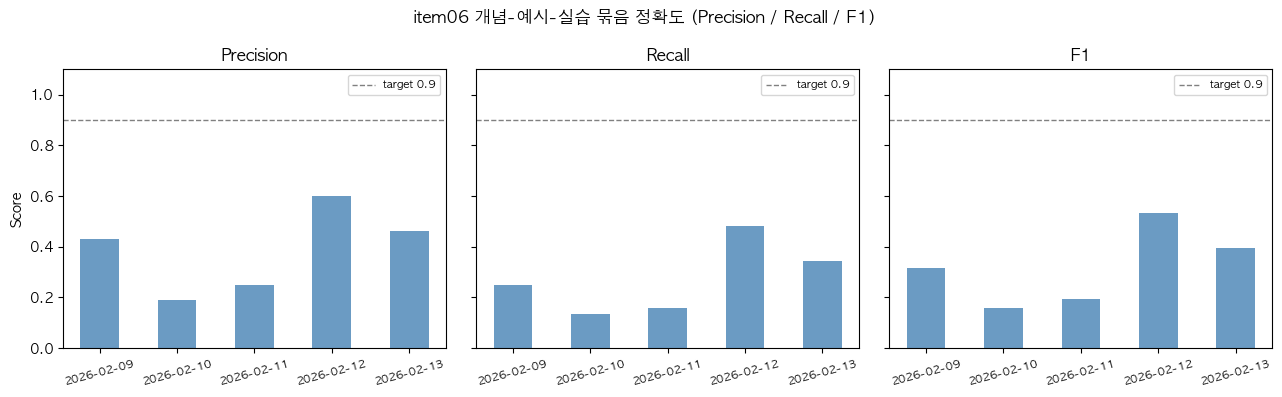

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (col, label) in zip(axes, [("precision", "Precision"), ("recall", "Recall"), ("f1", "F1")]):
    x = range(len(summary_df))
    ax.bar(x, summary_df[col], 0.5, color="steelblue", alpha=0.8)
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="target 0.9")
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary_df["date"], rotation=15, fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Score")
fig.suptitle("item06 개념-예시-실습 묶음 정확도 (Precision / Recall / F1)", fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
for date, r in results.items():
    if r["detail"].empty:
        continue
    detail = r["detail"]
    fn_rows = detail[(detail["gold"] == 1) & (detail["pred"] == 0)]
    fp_rows = detail[(detail["gold"] == 0) & (detail["pred"] == 1)]
    if fn_rows.empty and fp_rows.empty:
        continue
    print(f"\n{'='*60}")
    print(f"{date}")
    if not fn_rows.empty:
        print(f"  FN (놓친 아이템 {len(fn_rows)}건):")
        for _, row in fn_rows.iterrows():
            print(f"    [{row['type']}] {row['topic'][:35]} → {row['item'][:45]} ({row['reason']})")
    if not fp_rows.empty:
        print(f"  FP (과묶임 {len(fp_rows)}건):")
        for _, row in fp_rows.iterrows():
            print(f"    [{row['type']}] {row['topic'][:60]}")


2026-02-09
  FN (놓친 아이템 27건):
    [예시] REPLACE 함수 → REPLACE 문자열 함수 예시 (아이템 미매칭)
    [예시] SUBSTRING 함수의 다양한 사용법과 표준 → RIGHT 함수 예시 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → 이름과 직업 연결 과제 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → 직업 세 글자 추출 과제 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → CONCAT, 대문자 변환, 문자열 추가 연습 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → RPAD/LPAD 기능 및 오버플로우 테스트 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → 조건부 RPAD 적용 과제 (IF, LENGTH 함수 활용) (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → Q19-1 CASE 문으로 문자열 처리 과제 (아이템 미매칭)
    [실습] SUBSTRING 함수의 다양한 사용법과 표준 → Q24 REPLACE 연습용 테이블 생성 (아이템 미매칭)
    [실습] TO_BASE64 함수 → 아스키 코드 BASE64 인코딩 과제 (아이템 미매칭)
    [실습] TO_BASE64 함수 → 나머지 Base64 인코딩 실습 (아이템 미매칭)
    [실습] TO_BASE64 함수 → 특수문자/이모지 Base64 인코딩 실습 (아이템 미매칭)
    [예시] SQL에서의 파일 처리와 Base64 함수 → BASE64 인코딩 과정 (소문자 'abc') (아이템 미매칭)
    [예시] SQL에서의 파일 처리와 Base64 함수 → FROM_BASE64 함수 디코딩 시연 (아이템 미매칭)
    [예시] SQL에서의 파일 처리와 Base64 함수 → 환경에 따른 디코딩 결과 차이 (16진수) (아이템 미매칭)


In [35]:
all_detail = pd.concat(
    [r["detail"].assign(date=date) for date, r in results.items() if not r["detail"].empty],
    ignore_index=True,
)

print("=== 유형별 묶음 정확도 (전체 날짜 합산) ===")
for item_type in ["예시", "실습"]:
    sub = all_detail[all_detail["type"] == item_type]
    if sub.empty:
        continue
    tp = ((sub["gold"] == 1) & (sub["pred"] == 1)).sum()
    fn = ((sub["gold"] == 1) & (sub["pred"] == 0)).sum()
    fp = ((sub["gold"] == 0) & (sub["pred"] == 1)).sum()
    p  = tp / (tp + fp) if tp + fp > 0 else 0.0
    r  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2*p*r/(p+r) if p+r > 0 else 0.0
    print(f"  {item_type}: TP={tp} FN={fn} FP={fp}  P={p:.3f} R={r:.3f} F1={f1:.3f}")

=== 유형별 묶음 정확도 (전체 날짜 합산) ===
  예시: TP=38 FN=47 FP=30  P=0.559 R=0.447 F1=0.497
  실습: TP=12 FN=87 FP=47  P=0.203 R=0.121 F1=0.152
